In [72]:
import pandas as pd
from sklearn.cluster import k_means
import joblib
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer

In [73]:
import hashlib

np.random.seed(42)
n_clients = 200

client_ids = [hashlib.sha256(f'client_{i}'.encode()).hexdigest()[:12] for i in range(n_clients)]

rfm_data = pd.DataFrame({
    'cliente': client_ids,
    'recencia': np.random.randint(1, 800, size=n_clients),
    'frecuencia': np.random.randint(1, 100, size=n_clients),
    'montoventapesos': np.round(np.random.uniform(10, 500000, size=n_clients), 2)
})

rfm_data = rfm_data.set_index("cliente")

In [74]:
rfm_data.sort_values(by='frecuencia', ascending=True)

,recencia,frecuencia,montoventapesos
cliente,,,
9d0348015fca,59,1,163332.35
edb10bc43809,703,1,8590.38
f6f977abe20c,749,1,471946.36
e60de7d0a74e,314,2,419468.36
2842d673085c,682,2,135778.74
...,...,...,...
7d7fd928e829,727,99,7662.12
003fbaa40f3e,392,99,340810.02
ca5caec2945d,419,99,130354.66


In [75]:
# Loading the job file
rfm = joblib.load("clustering_rfm_model.pkl")
model = rfm['kmeans']
scaler = rfm['preprocessor']
reduction = rfm['pca']

In [76]:
# Scaling features
x_scaled = scaler.transform(rfm_data)

x_scaled = scaler.transform(rfm_data)

# Making prediction with the model
transform_data = model.predict(x_scaled)


In [77]:
pca = reduction.transform(x_scaled)

In [79]:
rfm_data['pca1'] = pca[:,0]
rfm_data['pca2'] = pca[:,1]

rfm_data['cluster'] = transform_data 

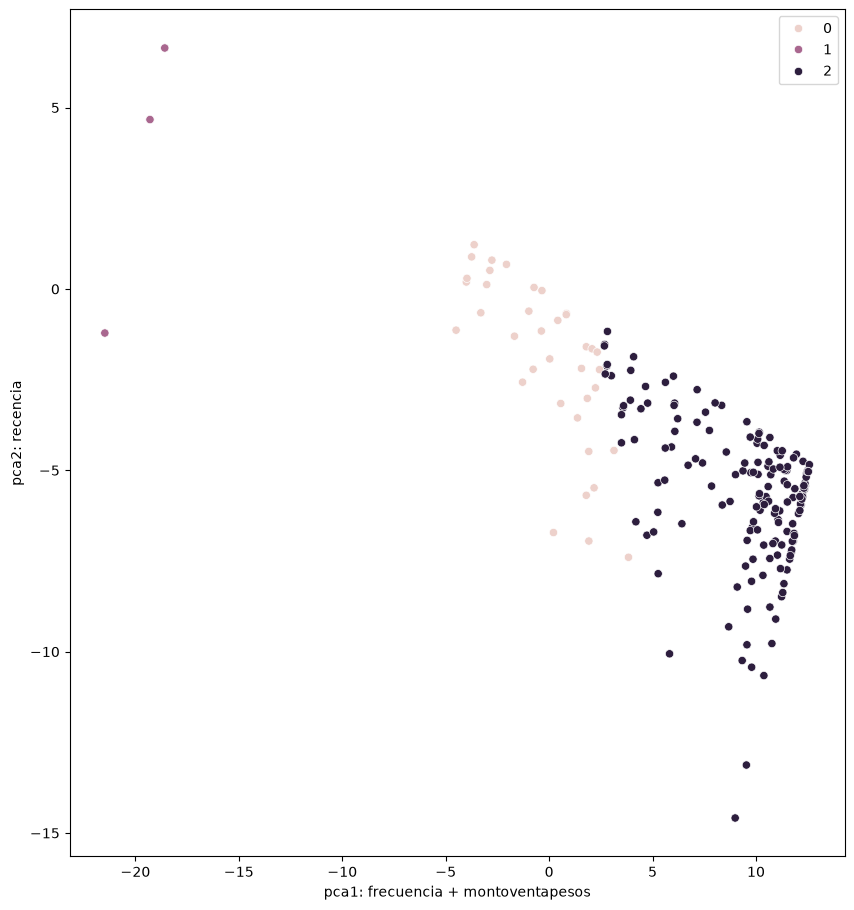

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,11))

sns.scatterplot(
    data=rfm_data,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia')
plt.legend(loc = 'upper right')